# **Lab - 5**

## **Aim**


*   The aim of this code is to illustrate the practical application of time series modeling techniques, which helps in generating synthetic data, analyze its properties, and perform forecasting using ARIMA and ARMA methodologies.



## **Program**

In [ ]:
# ============================================================
# IMPORT REQUIRED LIBRARIES
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import acf
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

# For reproducibility
np.random.seed(10)


In [ ]:
n = 200
theta = 0.7

noise = np.random.normal(0, 1, n)
y = np.zeros(n)

for t in range(1, n):
    y[t] = noise[t] + theta * noise[t - 1]

series = pd.Series(y)


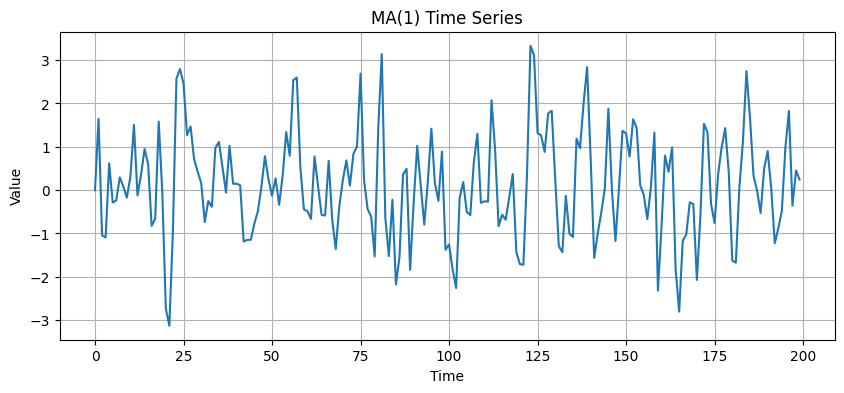

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(series)
plt.title("MA(1) Time Series")
plt.xlabel("Time")
plt.ylabel("Value")
plt.grid(True)
plt.show()


In [ ]:
acf_vals = acf(series, nlags=20)

print("ACF Values:")
for i, v in enumerate(acf_vals):
    print(f"Lag {i}: {v:.3f}")


ACF Values:
Lag 0: 1.000
Lag 1: 0.466
Lag 2: -0.038
Lag 3: -0.110
Lag 4: -0.110
Lag 5: -0.011
Lag 6: -0.005
Lag 7: -0.154
Lag 8: -0.239
Lag 9: -0.128
Lag 10: 0.033
Lag 11: 0.077
Lag 12: 0.039
Lag 13: 0.011
Lag 14: 0.012
Lag 15: 0.062
Lag 16: 0.090
Lag 17: 0.046
Lag 18: -0.050
Lag 19: -0.128
Lag 20: -0.107


In [ ]:
ar = np.array([1, -0.6])   # AR(1)
ma = np.array([1, 0.5])    # MA(1)

arma_process = ArmaProcess(ar, ma)
arma_data = arma_process.generate_sample(nsample=200)

arma_series = pd.Series(arma_data)


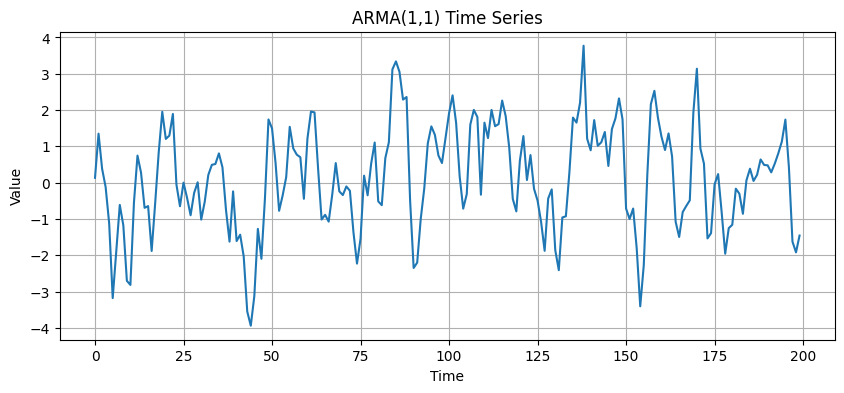

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(arma_series)
plt.title("ARMA(1,1) Time Series")
plt.xlabel("Time")
plt.ylabel("Value")
plt.grid(True)
plt.show()


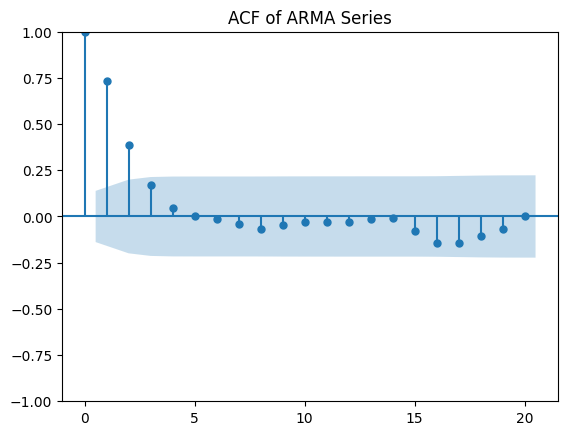

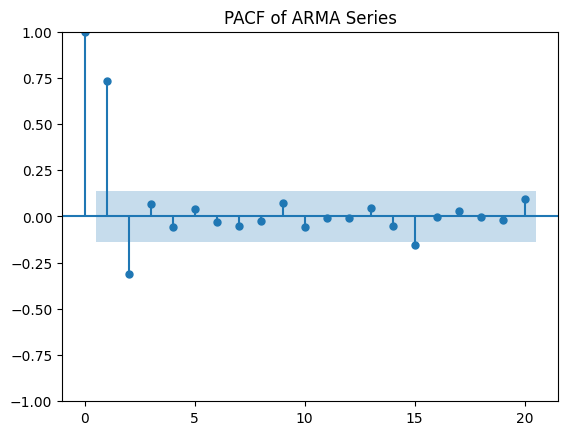

In [ ]:
plot_acf(arma_series, lags=20)
plt.title("ACF of ARMA Series")
plt.show()

plot_pacf(arma_series, lags=20)
plt.title("PACF of ARMA Series")
plt.show()


In [ ]:
trend = np.arange(200) * 0.2
noise = np.random.normal(0, 1, 200)

non_stationary = trend + noise
data = pd.Series(non_stationary)


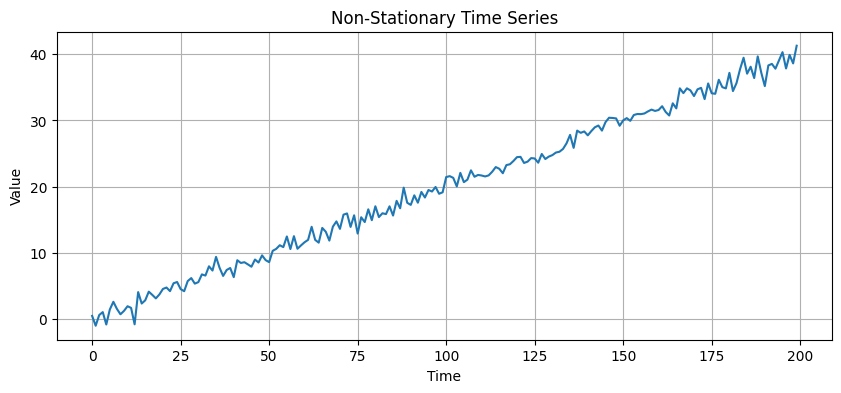

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(data)
plt.title("Non-Stationary Time Series")
plt.xlabel("Time")
plt.ylabel("Value")
plt.grid(True)
plt.show()


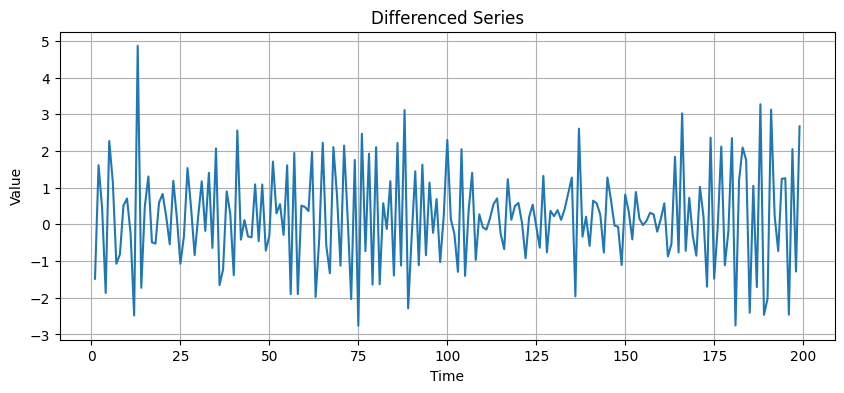

In [ ]:
data_diff = data.diff().dropna()

plt.figure(figsize=(10, 4))
plt.plot(data_diff)
plt.title("Differenced Series")
plt.xlabel("Time")
plt.ylabel("Value")
plt.grid(True)
plt.show()


In [ ]:
train = data[:160]
test = data[160:]

model = ARIMA(train, order=(1, 1, 1))
model_fit = model.fit()

print(model_fit.summary())


                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  160
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -229.721
Date:                Mon, 22 Dec 2025   AIC                            465.443
Time:                        04:52:45   BIC                            474.649
Sample:                             0   HQIC                           469.181
                                - 160                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3131      0.118     -2.646      0.008      -0.545      -0.081
ma.L1         -0.3253      0.127     -2.556      0.011      -0.575      -0.076
sigma2         1.0503      0.119      8.794      0.0

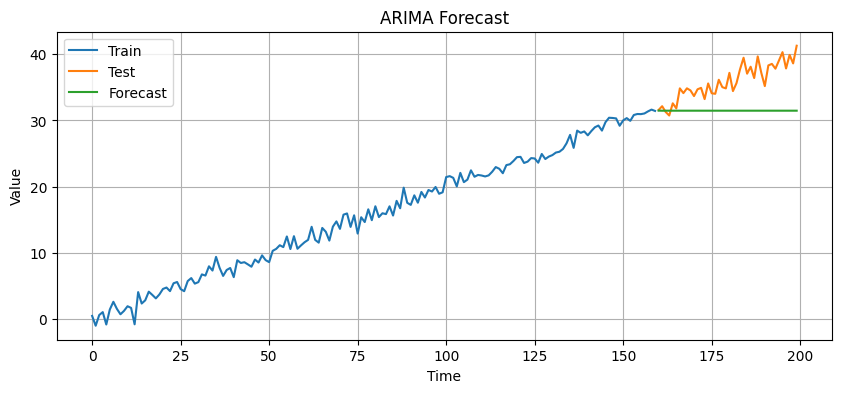

In [ ]:
forecast = model_fit.forecast(steps=len(test))

plt.figure(figsize=(10, 4))
plt.plot(train, label="Train")
plt.plot(test, label="Test")
plt.plot(forecast, label="Forecast")
plt.legend()
plt.title("ARIMA Forecast")
plt.xlabel("Time")
plt.ylabel("Value")
plt.grid(True)
plt.show()


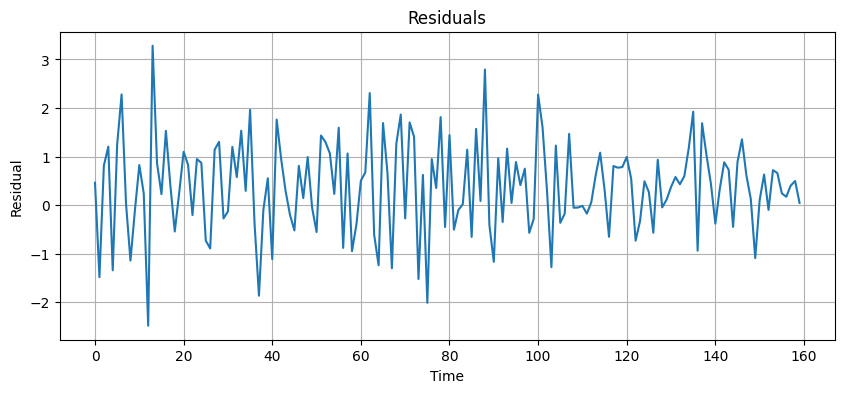

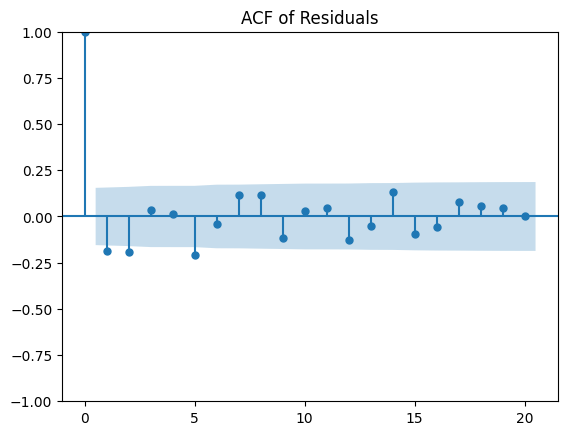

In [ ]:
residuals = model_fit.resid

plt.figure(figsize=(10, 4))
plt.plot(residuals)
plt.title("Residuals")
plt.xlabel("Time")
plt.ylabel("Residual")
plt.grid(True)
plt.show()

plot_acf(residuals, lags=20)
plt.title("ACF of Residuals")
plt.show()
